In [1]:
# link = "https://drive.google.com/file/d/10D-K2jXZ96BeznXuYcHwom90g6cp_L6Q/view?usp=sharing"

In [2]:
# # download the file
# import gdown
# gdown.download(link, "FMOCA.zip", quiet=False, fuzzy=True) 

In [57]:
import cv2
import numpy as np

flow_image = cv2.imread("fullmoca/FlowImages_gap1/arctic_fox/00134.png")
input_image = cv2.imread("fullmoca/MoCA-Video-Test/arctic_fox/Frame/00134.jpg")

flow_image = cv2.resize(flow_image, (input_image.shape[1], input_image.shape[0]))
# convert flow into dx and dy
hsv = cv2.cvtColor(flow_image, cv2.COLOR_BGR2HSV)

angle = hsv[:, :, 0] * (2 * np.pi / 180)
magnitude = hsv[:, :, 1] / 255.0

dx = magnitude * np.cos(angle)
dy = magnitude * np.sin(angle)

In [58]:

mag, ang = cv2.cartToPolar(dx, dy)
intensity_gray = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
intensity = np.stack([np.zeros_like(intensity_gray), np.zeros_like(intensity_gray), intensity_gray], axis=-1)
blended = cv2.addWeighted(input_image, 1, intensity, 0.3, 0)

In [59]:
from PIL import Image
pil_blended = Image.fromarray(blended)


In [ ]:
from openai import OpenAI
import dotenv 
import os
import json

dotenv.load_dotenv()

from pydantic import BaseModel, Field
class Response(BaseModel):
    bbox: list = Field(..., description="The bounding box.")

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=os.getenv("OPENROUTER_API_KEY"),
)

import base64
from io import BytesIO
def encode_image_for_llm(image):
    if isinstance(image, Image.Image):
        pil_image = image
    elif isinstance(image, dict):
        if image.get("bytes") is not None:
            pil_image = Image.open(BytesIO(image["bytes"]))
        elif image.get("path"):
            pil_image = Image.open(image["path"])
        else:
            raise ValueError("image dictionary missing both 'bytes' and 'path'")
    else:
        raise TypeError(f"Unsupported image type: {type(image)}")
    buffer = BytesIO()
    pil_image.convert("RGB").save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


completion = client.chat.completions.parse(
  extra_body={
      "provider":{
          "order": ["parasail/fp8"],
          "allow_fallbacks": False
      }
  },
  model="qwen/qwen3-vl-235b-a22b-instruct",
  messages=[
              {
                "role": "user",
                "content": [
                  {
                    "type": "text",
                    "text": "Please find an camflagued animal in this image and provide the bounding box, it MIGHT be highlighted in blue."
                  },
                  {
                    "type": "image_url",
                    "image_url": {
                      "url": encode_image_for_llm(pil_blended)
                    }
                  }
                ]
              }
            ],
  response_format=Response
)
print(completion.choices[0].message.content) 
ans = json.loads(completion.choices[0].message.content)
bounding_box = ans["bbox"]
height, width, _ = input_image.shape
abs_y1 = int(bounding_box[1] / 1000 * height) 
abs_x1 = int(bounding_box[0] / 1000 * width)
abs_y2 = int(bounding_box[3] / 1000 * height)
abs_x2 = int(bounding_box[2] / 1000 * width)


{
  "bbox": [466, 509, 660, 769]
}


In [64]:
encode_image_for_llm(pil_blended)

'...'

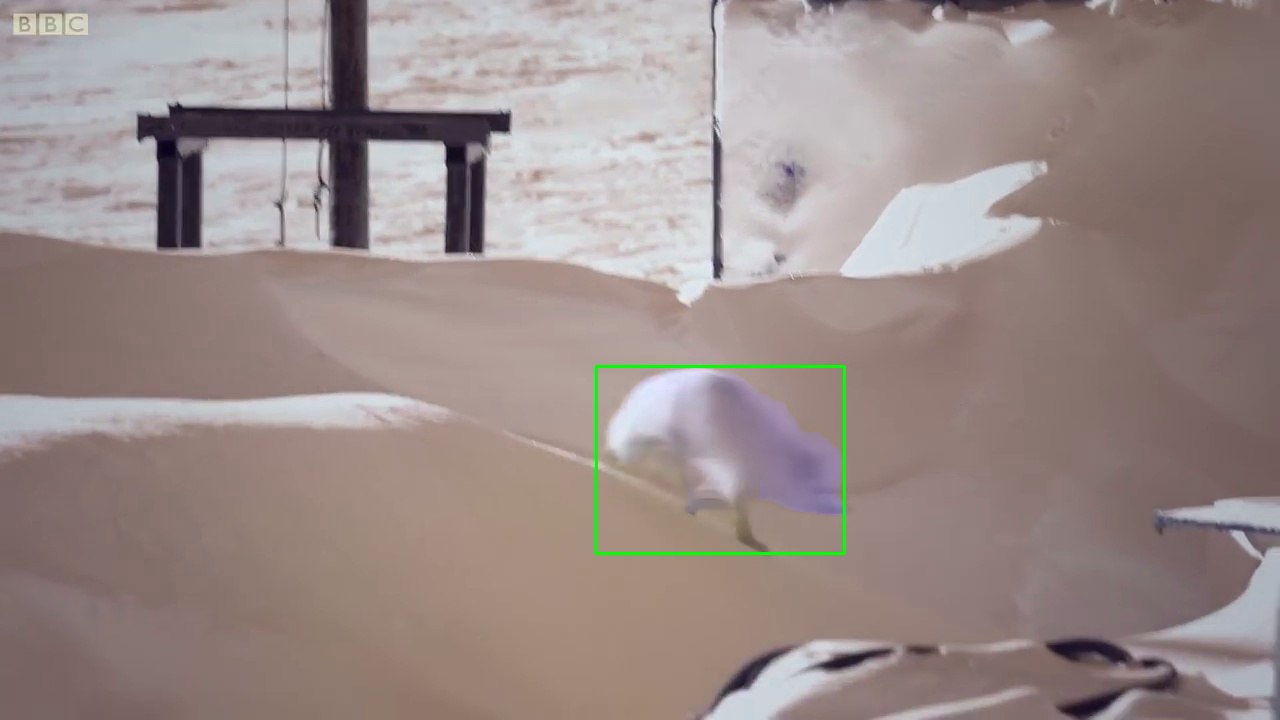

In [63]:
# draw the bounding box
bounding_box = ans["bbox"]
height, width, _ = input_image.shape
abs_y1 = int(bounding_box[1] / 1000 * height) 
abs_x1 = int(bounding_box[0] / 1000 * width)
abs_y2 = int(bounding_box[3] / 1000 * height)
abs_x2 = int(bounding_box[2] / 1000 * width)
 
blended_copy = blended.copy()
cv2.rectangle(blended_copy, (abs_x1, abs_y1), (abs_x2, abs_y2), (0, 255, 0), 2)
Image.fromarray(blended_copy) 

In [5]:
import pickle
with open("ibex_res_frames.pkl", "rb") as f:
    frames = pickle.load(f) 

In [8]:
frames.shape

(118, 720, 3840, 3)

In [15]:
import imageio.v2 as iio
with iio.imopen("ibex.mp4", "w", plugin="pyav") as out_file:
    out_file.init_video_stream("vp9", fps=15)

    for frame in frames:
        out_file.write_frame(frame)